Question 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3] 
Y_cols = D[:, 3:]

In [5]:
def fit_line_tls(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    A = np.column_stack([x - x_mean, y - y_mean])
    U, S, Vt = np.linalg.svd(A)
    a, b = Vt[-1]
    c = -(a * x_mean + b * y_mean)
    norm = np.sqrt(a**2 + b**2)
    return a / norm, b / norm, c / norm

Question 1 (a)

Question 1(a): Total Least Squares — Line 1

Number of points: 100

Line parameters (ax + by + c = 0):
  a = 0.773562
  b = -0.633721
  c = -3.794192

Slope-intercept form: y = 1.220666x + (-5.987165)

Mean orthogonal distance: 0.405888
Sum of squared distances: 25.138039


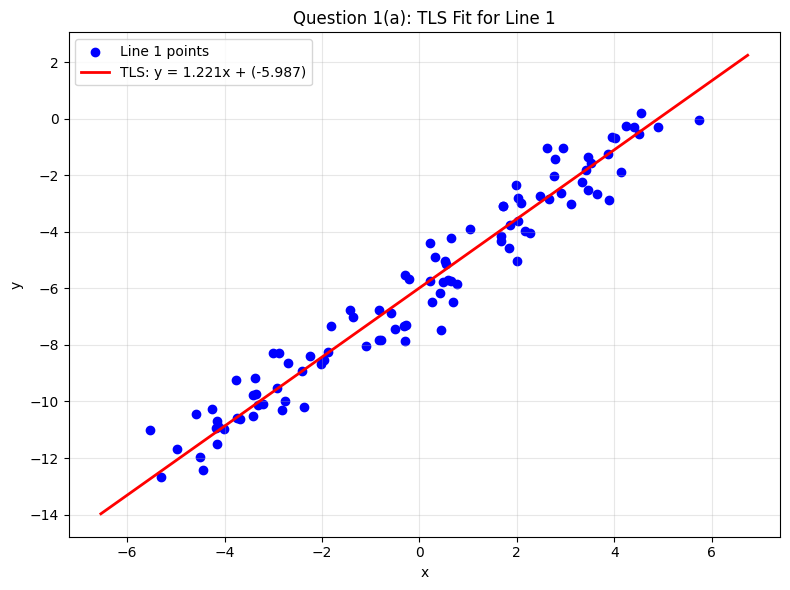


Plot saved as q1a_tls_line1.png


In [7]:
print("=" * 60)
print("Question 1(a): Total Least Squares — Line 1")
print("=" * 60)

x1 = D[:, 0]
y1 = D[:, 3]

a, b, c = fit_line_tls(x1, y1)

print(f"\nNumber of points: {len(x1)}")
print(f"\nLine parameters (ax + by + c = 0):")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")
print(f"  c = {c:.6f}")

if abs(b) > 1e-10:
    slope = -a / b
    intercept = -c / b
    print(f"\nSlope-intercept form: y = {slope:.6f}x + ({intercept:.6f})")

distances = np.abs(a * x1 + b * y1 + c)
print(f"\nMean orthogonal distance: {np.mean(distances):.6f}")
print(f"Sum of squared distances: {np.sum(distances**2):.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, c='blue', label='Line 1 points')
x_range = np.linspace(np.min(x1) - 1, np.max(x1) + 1, 100)
if abs(b) > 1e-10:
    y_fit = slope * x_range + intercept
    plt.plot(x_range, y_fit, 'r-', linewidth=2, label=f'TLS: y = {slope:.3f}x + ({intercept:.3f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Question 1(a): TLS Fit for Line 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls_line1.png', dpi=150)
plt.show()
print("\nPlot saved as q1a_tls_line1.png")

Question 1 (b)


Question 1(b): RANSAC — Finding 3 Lines

Total points: 300

--- Line 1 ---
  Equation: -0.413720x + -0.910404y + 1.900344 = 0
  Slope-intercept: y = -0.454436x + (2.087364)
  Inliers: 84 points

--- Line 2 ---
  Equation: -0.714100x + 0.700043y + -0.803599 = 0
  Slope-intercept: y = 1.020080x + (1.147927)
  Inliers: 66 points

--- Line 3 ---
  Equation: 0.787989x + -0.615689y + -3.694794 = 0
  Slope-intercept: y = 1.279849x + (-6.001072)
  Inliers: 66 points


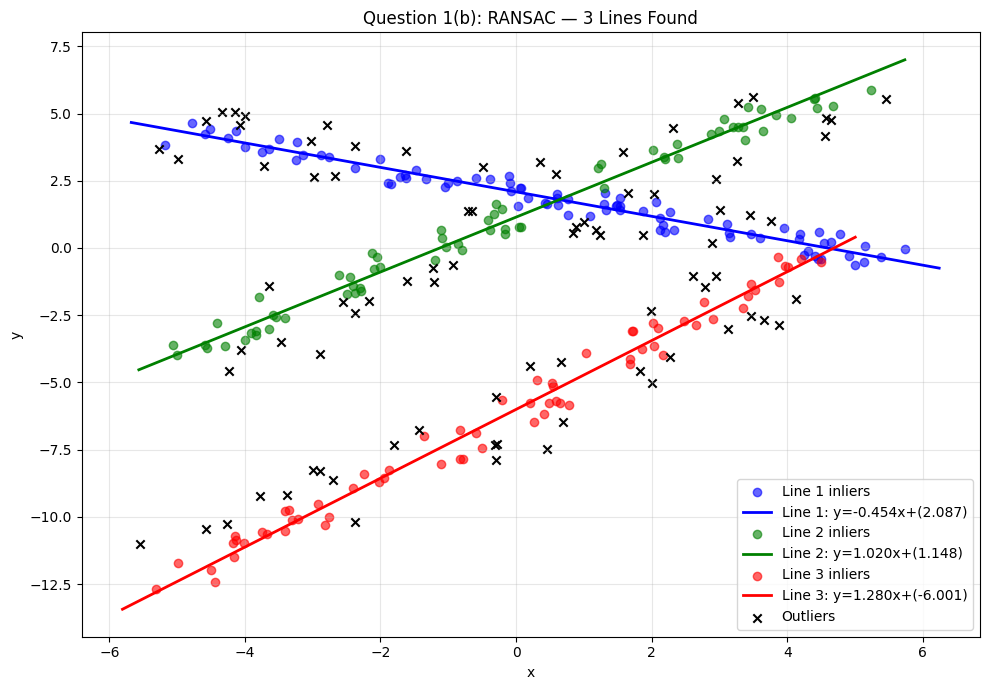


Plot saved as q1b_ransac_3lines.png


In [9]:
print("\n" + "=" * 60)
print("Question 1(b): RANSAC — Finding 3 Lines")
print("=" * 60)

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f"\nTotal points: {len(X_all)}")


def ransac_line(X, Y, n_iter=5000, threshold=0.5):
    best_inliers = None
    best_count = 0
    best_params = None
    n = len(X)

    for _ in range(n_iter):
        idx = np.random.choice(n, 2, replace=False)
        x_s, y_s = X[idx], Y[idx]

        if np.allclose(x_s[0], x_s[1]) and np.allclose(y_s[0], y_s[1]):
            continue

        a, b, c = fit_line_tls(x_s, y_s)

        dists = np.abs(a * X + b * Y + c)

        inliers = dists < threshold
        count = np.sum(inliers)

        if count > best_count:
            best_count = count
            best_inliers = inliers.copy()
            best_params = (a, b, c)

    if best_inliers is not None and np.sum(best_inliers) >= 2:
        a, b, c = fit_line_tls(X[best_inliers], Y[best_inliers])
        best_params = (a, b, c)

    return best_params, best_inliers


np.random.seed(42)
remaining_mask = np.ones(len(X_all), dtype=bool)
lines_found = []
inlier_sets = []
colors_list = ['blue', 'green', 'red']

for line_num in range(1, 4):
    X_rem = X_all[remaining_mask]
    Y_rem = Y_all[remaining_mask]

    if len(X_rem) < 2:
        print(f"\nNot enough points for Line {line_num}")
        break

    params, inliers_local = ransac_line(X_rem, Y_rem, n_iter=5000, threshold=0.5)
    a, b, c = params

    print(f"\n--- Line {line_num} ---")
    print(f"  Equation: {a:.6f}x + {b:.6f}y + {c:.6f} = 0")
    if abs(b) > 1e-10:
        print(f"  Slope-intercept: y = {-a/b:.6f}x + ({-c/b:.6f})")
    print(f"  Inliers: {np.sum(inliers_local)} points")

    lines_found.append(params)
    rem_indices = np.where(remaining_mask)[0]
    inlier_global = rem_indices[inliers_local]
    inlier_sets.append(inlier_global)

    remaining_mask[inlier_global] = False

plt.figure(figsize=(10, 7))
for i, (params, inlier_idx) in enumerate(zip(lines_found, inlier_sets)):
    a, b, c = params
    xi = X_all[inlier_idx]
    yi = Y_all[inlier_idx]
    plt.scatter(xi, yi, c=colors_list[i], label=f'Line {i+1} inliers', alpha=0.6)

    x_range = np.linspace(np.min(xi) - 0.5, np.max(xi) + 0.5, 100)
    if abs(b) > 1e-10:
        y_fit = (-a * x_range - c) / b
        plt.plot(x_range, y_fit, color=colors_list[i], linewidth=2,
                 label=f'Line {i+1}: y={-a/b:.3f}x+({-c/b:.3f})')

if np.any(remaining_mask):
    plt.scatter(X_all[remaining_mask], Y_all[remaining_mask],
                c='black', marker='x', label='Outliers')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Question 1(b): RANSAC — 3 Lines Found')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac_3lines.png', dpi=150)
plt.show()
print("\nPlot saved as q1b_ransac_3lines.png")